In [1]:
!cd

C:\Users\nitin\PYL759\BTP\Project\src


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
import imageio.v3 as io
import os
import random
from tqdm import tqdm

## Configuration

### Simulation Parameters

In [2]:
wave = 500e-9
p = 5e-6
N = 256
Obj_size = 128

### Dataset Parameters

In [3]:
DATASET = 'celeba'
RAW_DATA_PATH = os.path.join('..', 'data', 'raw', DATASET, 'img_align_celeba')
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed', f'{DATASET}_{Obj_size}x{Obj_size}')
NUM_TRAIN = 5000
NUM_VAL = 1000
NUM_TEST = 1000

### Functions

In [8]:
def forward_transform(field):
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(field)))

def rgb2gray(rgb_image):
    return np.dot(rgb_image[...,:3], [0.2989, 0.5870, 0.1140])

def process_and_save(file_list, dest_path):
    print(f"Processing {len(file_list)} images for destination: {dest_path}")
    os.makedirs(dest_path, exist_ok=True)
    
    x0 = np.linspace(-(N - 1) / 2.0, (N - 1) / 2.0, N, endpoint=True)
    x, y = np.meshgrid(x0, x0)
    vortex_mask = np.exp(1j * np.arctan2(y, x))
    
    # Lists to hold the data before saving
    labels, inputs_A, inputs_B = [], [], []
    
    for filename in tqdm(file_list, desc=f"Creating dataset in {os.path.basename(dest_path)}"):
        try:
            raw_path = os.path.join(RAW_DATA_PATH, filename)
            img_raw = io.imread(raw_path)
            
            # Convert to grayscale
            img_gray = rgb2gray(img_raw)
            img_float = img_gray.astype(np.float64)
            
            # Resize and pad
            img_resized = resize(img_float, (Obj_size, Obj_size), anti_aliasing=True)
            obj_canvas = np.zeros((N, N), dtype=np.float64)
            pad_start = (N - Obj_size) // 2
            pad_end = pad_start + Obj_size
            obj_canvas[pad_start:pad_end, pad_start:pad_end] = img_resized

            img_norm = (obj_canvas - obj_canvas.min()) / (obj_canvas.max() - obj_canvas.min())
            label = img_norm 
            complex_obj = np.exp(1j * np.pi * label)

            # Input A: Plane Wave (Fraunhoffer)
            ft_plane = forward_transform(complex_obj)
            input_A = np.abs(ft_plane)
            
            # Input B: Vortex Illumination (Fraunhoffer)
            vortex_obj = complex_obj * vortex_mask
            ft_vortex = forward_transform(vortex_obj)
            input_B = np.abs(ft_vortex)
            
            # Add to lists
            labels.append(label)
            inputs_A.append(input_A)
            inputs_B.append(input_B)

        except Exception as e:
            print(f"\nWarning: Could not process file {filename}. Error: {e}")

    # Save datasets
    print("\nConverting lists to numpy arrays")
    labels_np = np.array(labels, dtype=np.float32)
    inputs_A_np = np.array(inputs_A, dtype=np.float32)
    inputs_B_np = np.array(inputs_B, dtype=np.float32)

    print("Saving files")
    np.save(os.path.join(dest_path, 'labels.npy'), labels_np)
    np.save(os.path.join(dest_path, 'inputs_plane_wave.npy'), inputs_A_np)
    np.save(os.path.join(dest_path, 'inputs_vortex.npy'), inputs_B_np)
    
    print(f"Successfully saved dataset to {dest_path}")
    print(f"Shapes: labels={labels_np.shape}, inputs_A={inputs_A_np.shape}, inputs_B={inputs_B_np.shape}")

In [9]:
if os.path.exists(RAW_DATA_PATH):
    print(f"Success! The folder was found at: {RAW_DATA_PATH}")
else:
    print(f"Error! The folder was NOT found at: {RAW_DATA_PATH}")

Success! The folder was found at: ..\data\raw\celeba\img_align_celeba


## Execution

Finding all image files
Found and shuffled 202599 images.
Processing 5000 images for destination: ..\data\processed\celeba_128x128\train


Creating dataset in train: 100%|███████████████████████████████████████████████████| 5000/5000 [04:23<00:00, 18.98it/s]



Converting lists to numpy arrays
Saving files
Successfully saved dataset to ..\data\processed\celeba_128x128\train
Shapes: labels=(5000, 256, 256), inputs_A=(5000, 256, 256), inputs_B=(5000, 256, 256)
Processing 1000 images for destination: ..\data\processed\celeba_128x128\val


Creating dataset in val: 100%|█████████████████████████████████████████████████████| 1000/1000 [00:52<00:00, 18.87it/s]



Converting lists to numpy arrays
Saving files
Successfully saved dataset to ..\data\processed\celeba_128x128\val
Shapes: labels=(1000, 256, 256), inputs_A=(1000, 256, 256), inputs_B=(1000, 256, 256)
Processing 1000 images for destination: ..\data\processed\celeba_128x128\test


Creating dataset in test: 100%|████████████████████████████████████████████████████| 1000/1000 [00:53<00:00, 18.74it/s]



Converting lists to numpy arrays
Saving files
Successfully saved dataset to ..\data\processed\celeba_128x128\test
Shapes: labels=(1000, 256, 256), inputs_A=(1000, 256, 256), inputs_B=(1000, 256, 256)

DATASET CREATION COMPLETE

Verifying one sample from the created test set


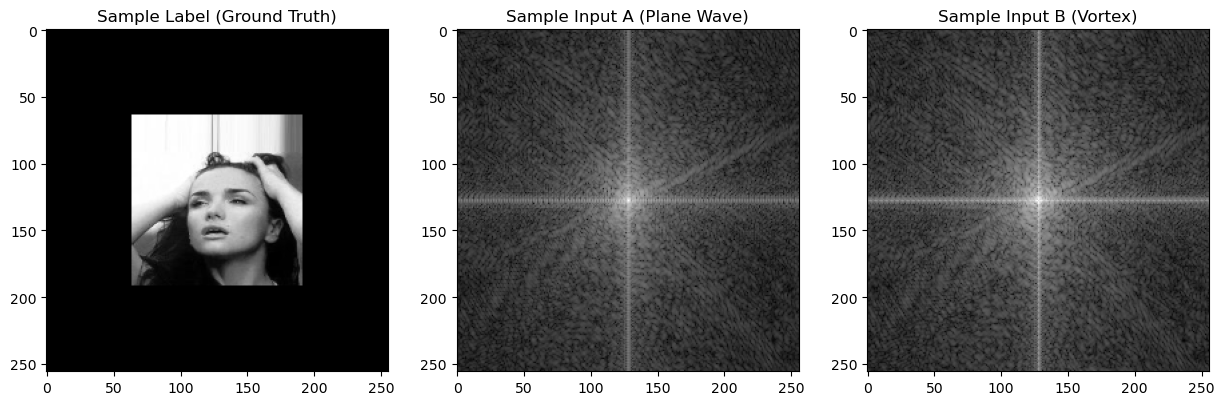

In [10]:
if __name__ == "__main__":
    print("Finding all image files")
    all_files = [f for f in os.listdir(RAW_DATA_PATH) if f.endswith('.jpg')]
    random.shuffle(all_files)
    print(f"Found and shuffled {len(all_files)} images.")
    
    # Create splits
    total_needed = NUM_TRAIN + NUM_VAL + NUM_TEST
    if len(all_files) < total_needed:
        raise ValueError(f"Not enough images in raw folder. Found {len(all_files)}, but need {total_needed}.")
        
    train_files = all_files[:NUM_TRAIN]
    val_files = all_files[NUM_TRAIN : NUM_TRAIN + NUM_VAL]
    test_files = all_files[NUM_TRAIN + NUM_VAL : total_needed]

    # Process and save each split
    process_and_save(train_files, os.path.join(PROCESSED_DATA_PATH, 'train'))
    process_and_save(val_files, os.path.join(PROCESSED_DATA_PATH, 'val'))
    process_and_save(test_files, os.path.join(PROCESSED_DATA_PATH, 'test'))

    print("\nDATASET CREATION COMPLETE")
    
    # Verification
    print("\nVerifying one sample from the created test set")
    verify_labels = np.load(os.path.join(PROCESSED_DATA_PATH, 'test', 'labels.npy'))
    verify_inputs_A = np.load(os.path.join(PROCESSED_DATA_PATH, 'test', 'inputs_plane_wave.npy'))
    verify_inputs_B = np.load(os.path.join(PROCESSED_DATA_PATH, 'test', 'inputs_vortex.npy'))

    sample_idx = 0
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(verify_labels[sample_idx], cmap='gray')
    axes[0].set_title('Sample Label (Ground Truth)')
    
    axes[1].imshow(np.log1p(verify_inputs_A[sample_idx]), cmap='gray')
    axes[1].set_title('Sample Input A (Plane Wave)')
    
    axes[2].imshow(np.log1p(verify_inputs_B[sample_idx]), cmap='gray')
    axes[2].set_title('Sample Input B (Vortex)')
    plt.show()